In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
matches = pd.read_csv("matches.csv")
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


Cleaning Data

In [3]:
matches.dropna(how="all")
matches['method'] = matches['method'].fillna('None')
matches['target_runs'] = matches['target_runs'].fillna(0)
matches['result_margin'] = matches['result_margin'].fillna(0)
matches['target_overs'] = matches['target_overs'].fillna(0)

In [4]:
matches['target_runs'] = matches['target_runs'].astype('int32')
matches['result_margin'] = matches['result_margin'].astype('int32')
matches['target_overs'] = matches['target_overs'].astype('int32')

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,None,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,None,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9,130,20,N,None,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5,166,20,N,None,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,None,BF Bowden,K Hariharan


Analyze Data

In [6]:
teams = matches['team1'].unique()
teams = np.append((matches['team2']).unique(),teams)
teams = np.unique(teams)
teams

array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals',
       'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans',
       'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders',
       'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors',
       'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Royal Challengers Bengaluru', 'Sunrisers Hyderabad'], dtype=object)

In [7]:
match_types = ["League", "3rd Place Play-Off" ,"Elimination Final", "Eliminator", "Qualifier 2", "Qualifier 1", "Semi Final", "Final"]

In [8]:
score = {team:0 for team in teams}
score['None'] = 0
score

{'Chennai Super Kings': 0,
 'Deccan Chargers': 0,
 'Delhi Capitals': 0,
 'Delhi Daredevils': 0,
 'Gujarat Lions': 0,
 'Gujarat Titans': 0,
 'Kings XI Punjab': 0,
 'Kochi Tuskers Kerala': 0,
 'Kolkata Knight Riders': 0,
 'Lucknow Super Giants': 0,
 'Mumbai Indians': 0,
 'Pune Warriors': 0,
 'Punjab Kings': 0,
 'Rajasthan Royals': 0,
 'Rising Pune Supergiant': 0,
 'Rising Pune Supergiants': 0,
 'Royal Challengers Bangalore': 0,
 'Royal Challengers Bengaluru': 0,
 'Sunrisers Hyderabad': 0,
 'None': 0}

In [9]:
score_assign = {m_type:i for i,m_type in enumerate(match_types,1)}
score_assign

{'League': 1,
 '3rd Place Play-Off': 2,
 'Elimination Final': 3,
 'Eliminator': 4,
 'Qualifier 2': 5,
 'Qualifier 1': 6,
 'Semi Final': 7,
 'Final': 8}

In [10]:
matches['winner'] = matches['winner'].fillna('None')

In [11]:
for i,match in matches.iterrows():
    score[match['winner']] += score_assign[match['match_type']]

In [12]:
score

{'Chennai Super Kings': 227,
 'Deccan Chargers': 42,
 'Delhi Capitals': 55,
 'Delhi Daredevils': 67,
 'Gujarat Lions': 13,
 'Gujarat Titans': 44,
 'Kings XI Punjab': 92,
 'Kochi Tuskers Kerala': 6,
 'Kolkata Knight Riders': 180,
 'Lucknow Super Giants': 24,
 'Mumbai Indians': 213,
 'Pune Warriors': 12,
 'Punjab Kings': 24,
 'Rajasthan Royals': 135,
 'Rising Pune Supergiant': 15,
 'Rising Pune Supergiants': 5,
 'Royal Challengers Bangalore': 138,
 'Royal Challengers Bengaluru': 7,
 'Sunrisers Hyderabad': 112,
 'None': 5}

In [13]:
winner = matches['winner']
winner

0             Kolkata Knight Riders
1               Chennai Super Kings
2                  Delhi Daredevils
3       Royal Challengers Bangalore
4             Kolkata Knight Riders
                   ...             
1090            Sunrisers Hyderabad
1091          Kolkata Knight Riders
1092               Rajasthan Royals
1093            Sunrisers Hyderabad
1094          Kolkata Knight Riders
Name: winner, Length: 1095, dtype: object

In [14]:
del score['None']

In [15]:
score

{'Chennai Super Kings': 227,
 'Deccan Chargers': 42,
 'Delhi Capitals': 55,
 'Delhi Daredevils': 67,
 'Gujarat Lions': 13,
 'Gujarat Titans': 44,
 'Kings XI Punjab': 92,
 'Kochi Tuskers Kerala': 6,
 'Kolkata Knight Riders': 180,
 'Lucknow Super Giants': 24,
 'Mumbai Indians': 213,
 'Pune Warriors': 12,
 'Punjab Kings': 24,
 'Rajasthan Royals': 135,
 'Rising Pune Supergiant': 15,
 'Rising Pune Supergiants': 5,
 'Royal Challengers Bangalore': 138,
 'Royal Challengers Bengaluru': 7,
 'Sunrisers Hyderabad': 112}

In [16]:
score_list = [score for score in score.values()]
score_list

[227, 42, 55, 67, 13, 44, 92, 6, 180, 24, 213, 12, 24, 135, 15, 5, 138, 7, 112]

In [17]:
data = {
    "team" : [team for team in teams],
    "score" : [score for score in score.values()]
}

In [18]:
index = ["teams","score"]
scores = pd.DataFrame(data)

In [19]:
scores

,team,score
0,Chennai Super Kings,227
1,Deccan Chargers,42
2,Delhi Capitals,55
3,Delhi Daredevils,67
4,Gujarat Lions,13
5,Gujarat Titans,44
6,Kings XI Punjab,92
7,Kochi Tuskers Kerala,6
8,Kolkata Knight Riders,180
9,Lucknow Super Giants,24


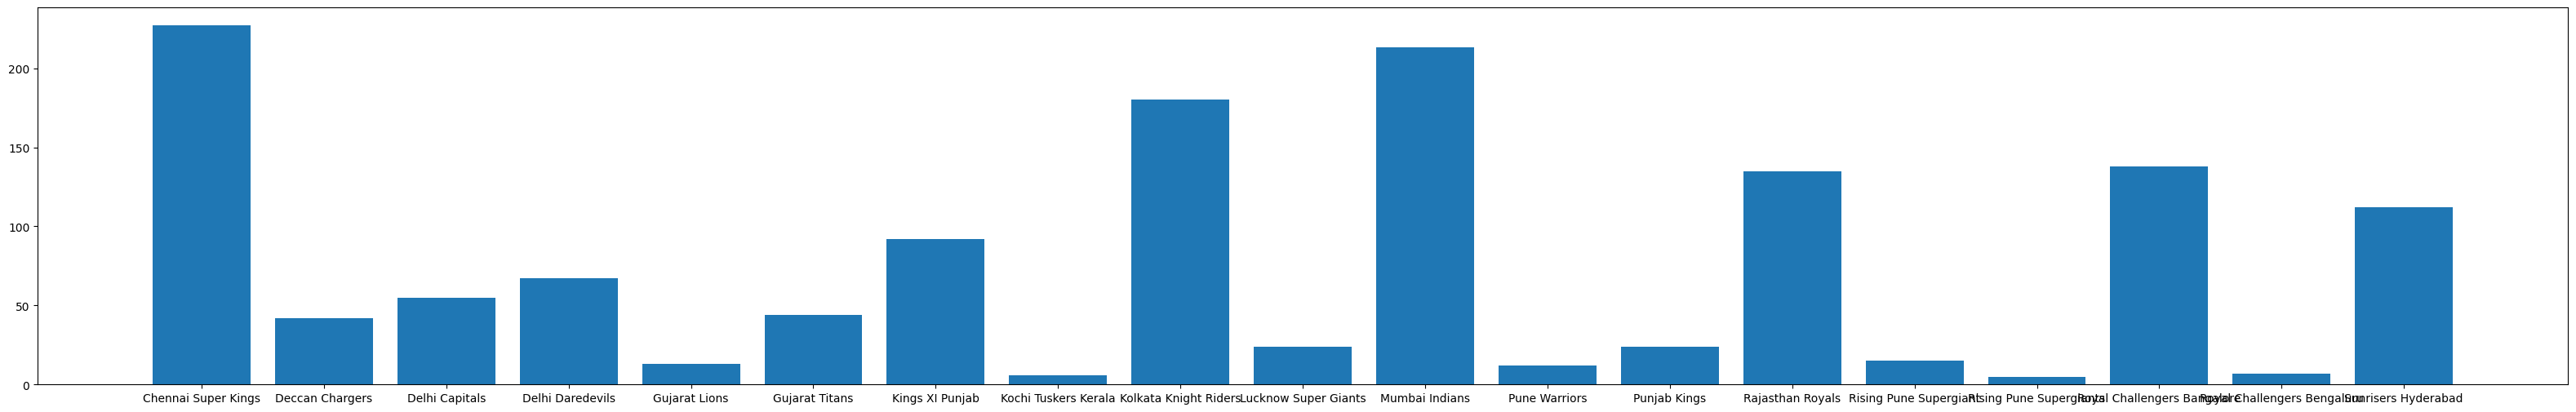

In [20]:
plt.figure(figsize=(40,6))
plt.bar(scores['team'],scores['score'])
plt.show()

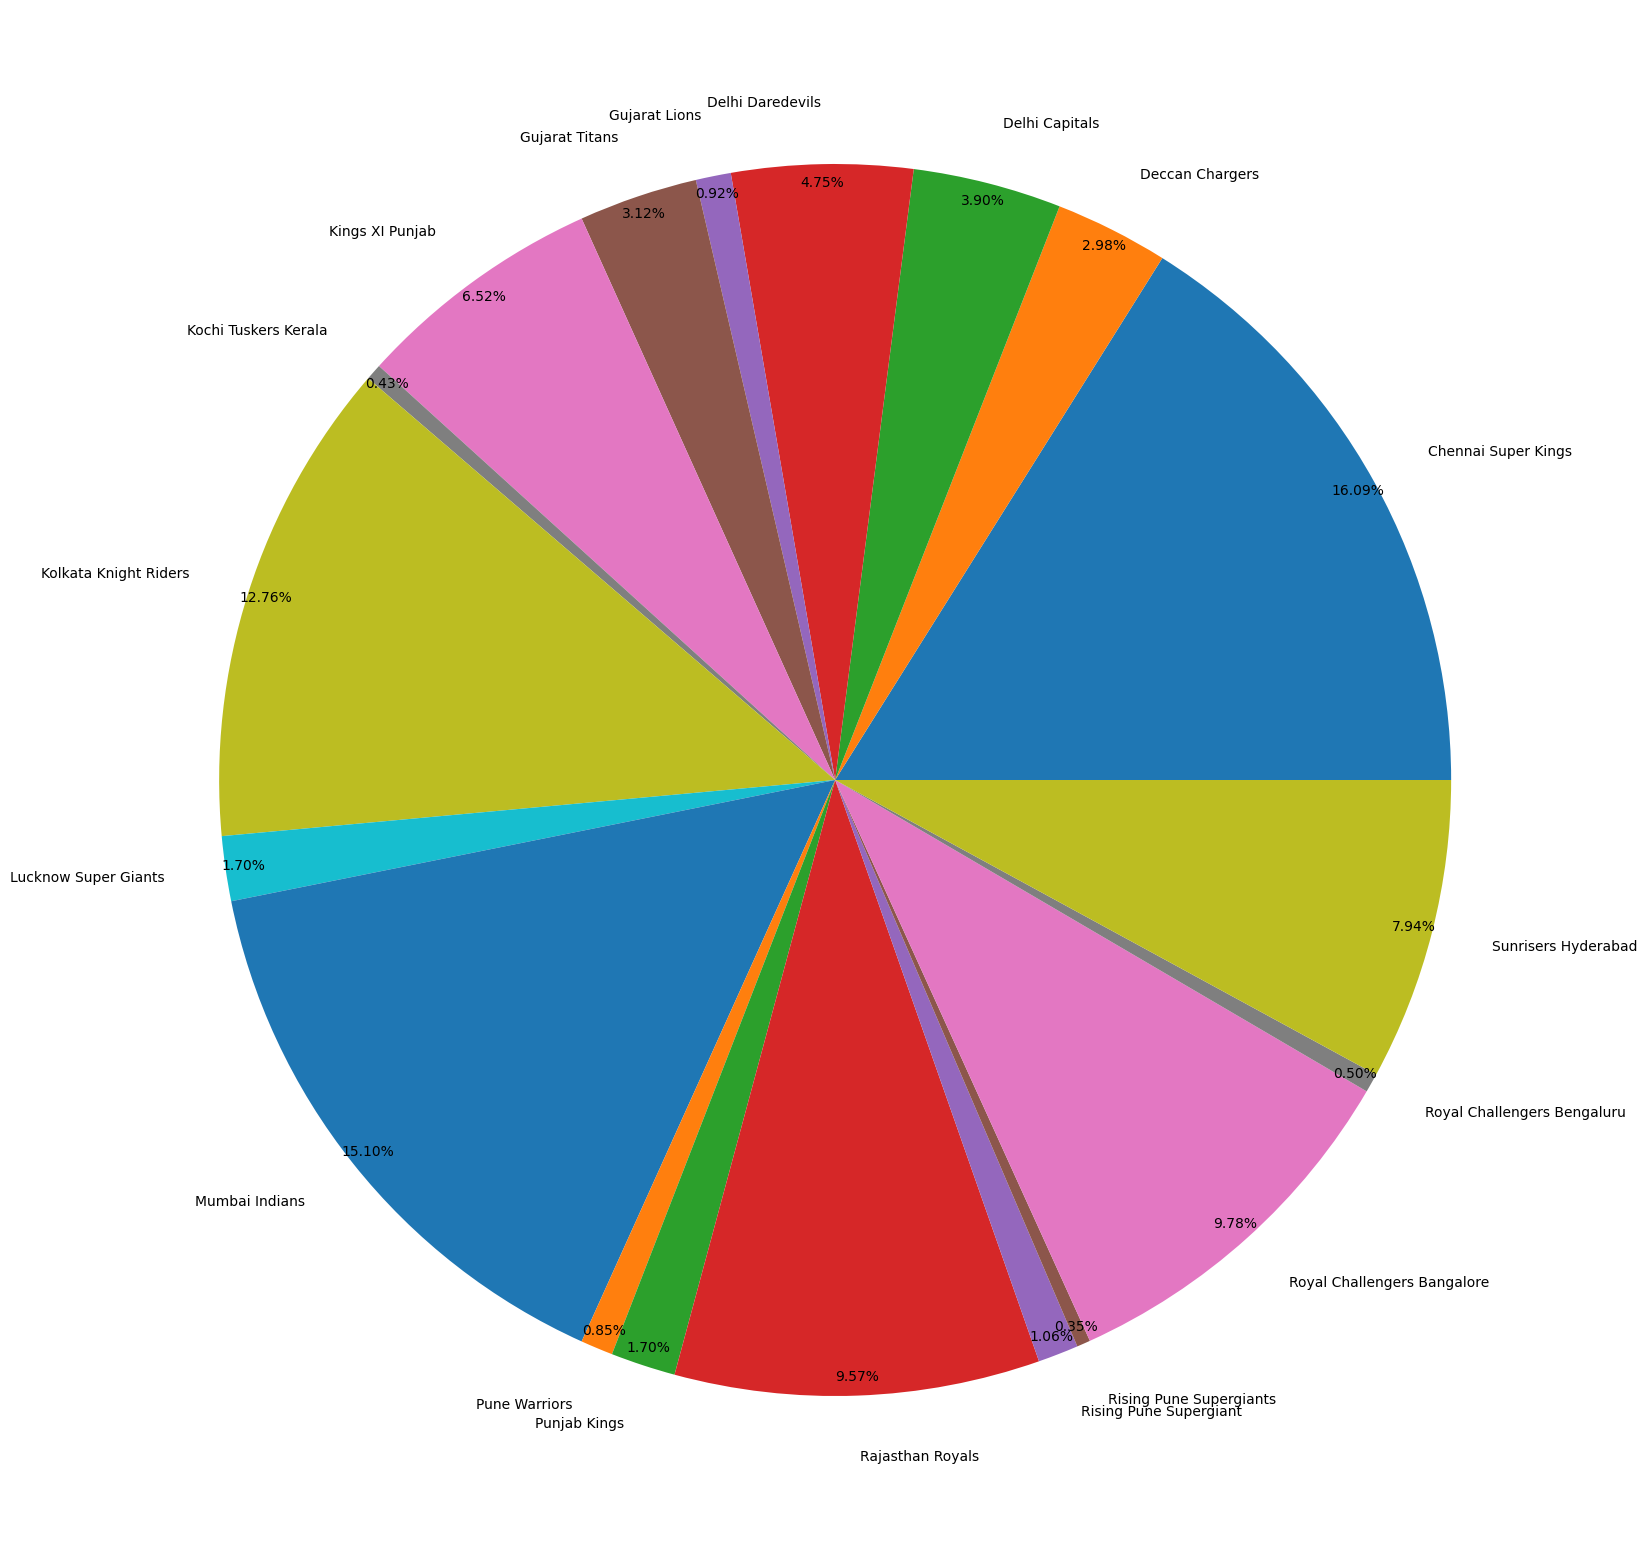

In [21]:
plt.figure(figsize=(20,20))
plt.pie(scores['score'], labels=teams, autopct="%.2f%%",pctdistance=0.97)
plt.show()